In [1]:
import os
import pandas as pd

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        df = pd.read_csv(os.path.join(dirname, filename))

# Step 1 - EDA


In [2]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Selector   583 non-null    object 
dtypes: float64(5), int64(4), object(2)
memory usage: 50.2+ KB


The **Selector** field is what our model needs to predict. It is categorical and has the following options:

* Liver Disease
* No Liver Disease

In [4]:
df['Selector'].unique()

array(['Liver Disease', 'No Liver Disease'], dtype=object)

In [5]:
print((df.isnull().sum()/(len(df)))*100)
print("There are no null values.")

Age          0.0
Gender       0.0
TB           0.0
DB           0.0
Alkphos      0.0
Sgpt         0.0
Sgot         0.0
TP           0.0
ALB          0.0
A/G Ratio    0.0
Selector     0.0
dtype: float64
There are no null values.


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
TB,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
DB,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkphos,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Sgpt,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Sgot,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
TP,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
ALB,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
A/G Ratio,583.0,0.946947,0.318495,0.3,0.7,0.93,1.1,2.8


# Step 2 - EDA graph plot

In [7]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64']).columns
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['Gender', 'Selector'], dtype='object')
Numerical Variables:
Index(['Age', 'Alkphos', 'Sgpt', 'Sgot'], dtype='object')


Age
Skew : -0.03


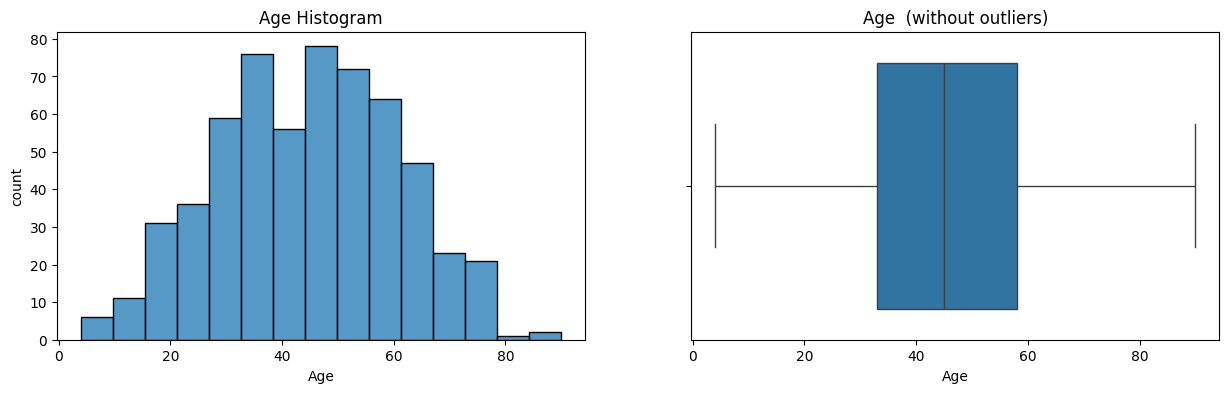

Alkphos
Skew : 3.77


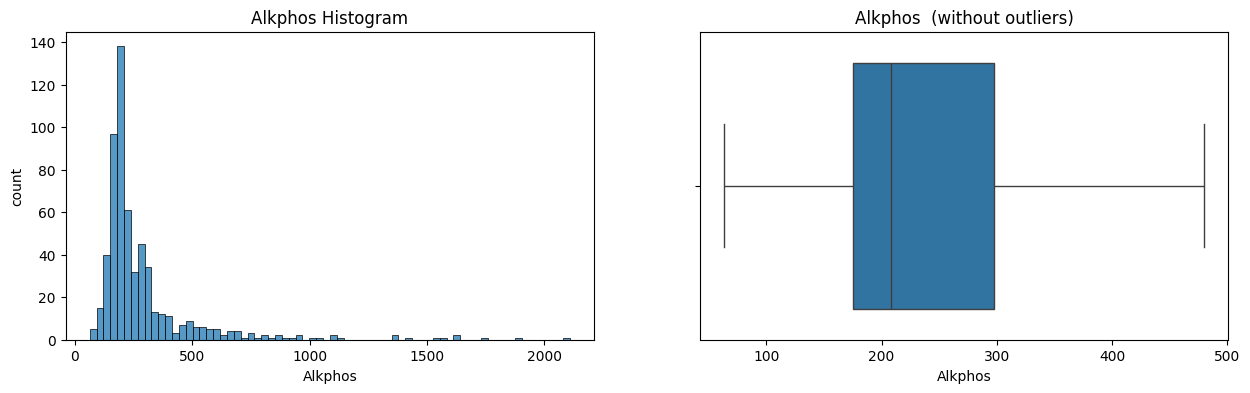

Sgpt
Skew : 6.55


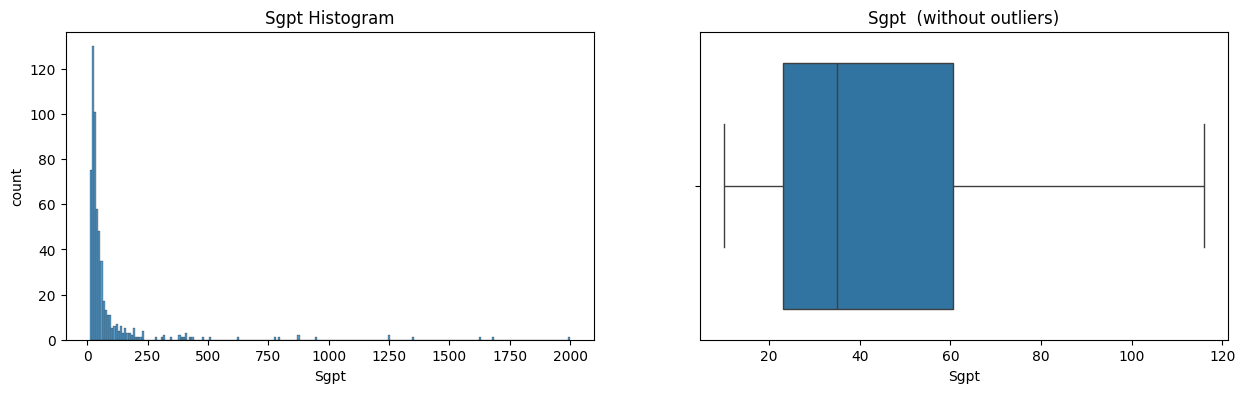

Sgot
Skew : 10.55


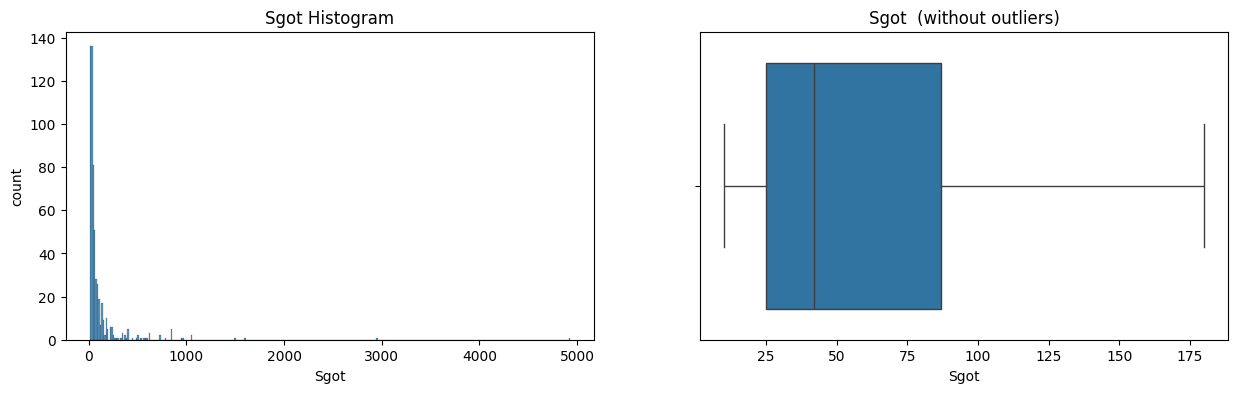

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize=(15, 4))
    
    # Histogram without outliers
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col)
    plt.ylabel('count')
    plt.title(f'{col} Histogram')
    
    # Boxplot without outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], showfliers=False)
    plt.title(f'{col}  (without outliers)')
    
    plt.show()

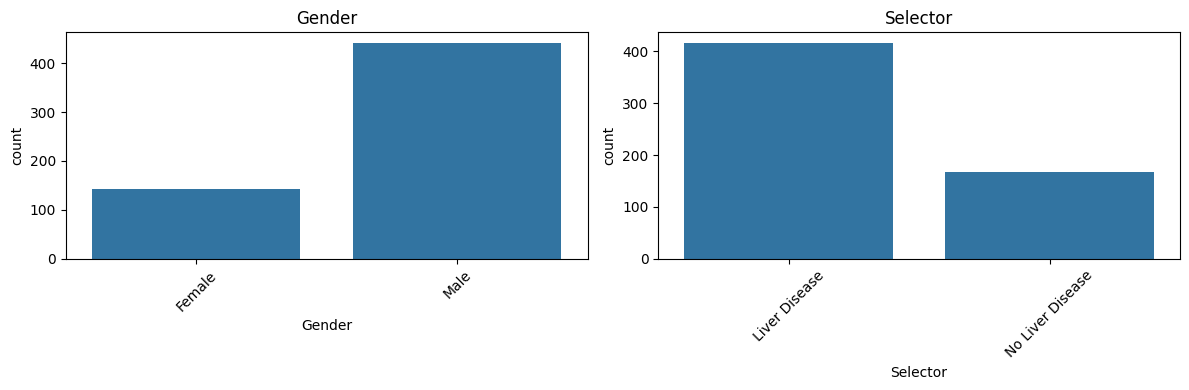

In [9]:
import math 

plots_per_row = 2

rows = math.ceil(len(cat_cols) / plots_per_row)

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

The dataset is heavily imbalanced, with most cases labelled as Liver Disease, so care is needed when creating the training and test splits.

# Step 3 - Bivariate Analysis

### On average, older age, along with elevated levels of alkaline phosphatase (alkphos), serum glutamic pyruvic transaminase (SQGPT), and serum glutamic oxaloacetic transaminase (SGOT), indicates the presence of liver disease.

/tmp/ipykernel_16/2870459676.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


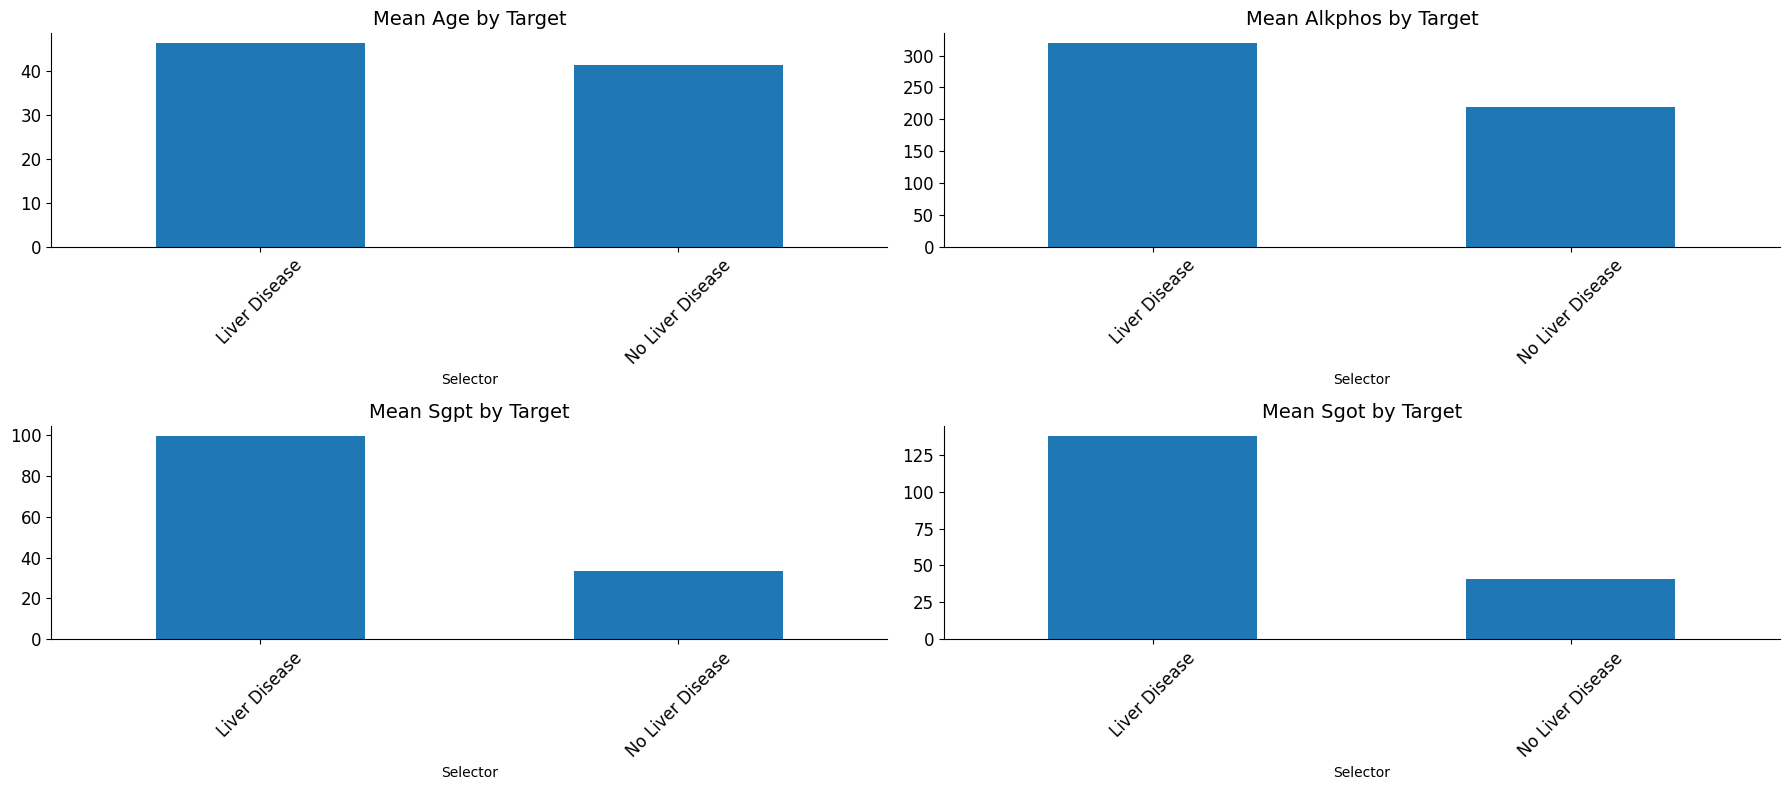

In [10]:
nrows, ncols = 2, 2

fig_h = nrows * 4.0   # try 2.4–3.0 depending on label length
fig_w = 18

fig, axarr = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), constrained_layout=True)
axes = axarr.ravel()

for i, num_col in enumerate(num_cols):
    (df.groupby('Selector')[num_col]
       .mean()
       .sort_values(ascending=False)
       .plot(kind='bar', ax=axes[i], fontsize=12))

    axes[i].set_title(f"Mean {num_col} by Target", fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, nrows*ncols):
    axes[j].axis('off')

plt.tight_layout()
sns.despine()
plt.show()

# This analysis indicates strong relationships among several features. SGOT is directly proportional to ALKPHOS and SGPT.

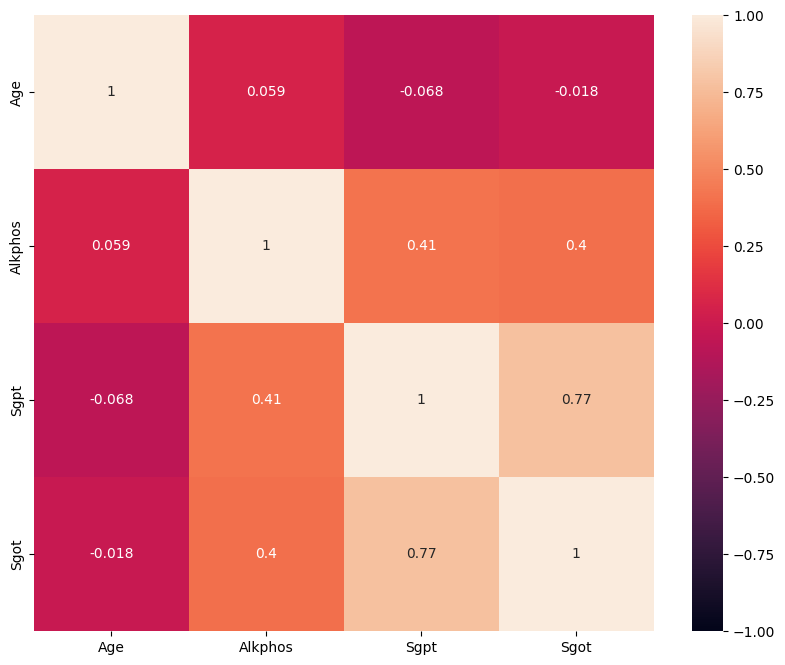

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(method='spearman'), annot = True, vmin = -1, vmax = 1)
plt.show()

In [12]:
df

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,No Liver Disease
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,Liver Disease
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,Liver Disease
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,Liver Disease


# Step 4 - Prepare data for ML

In [13]:
from sklearn.preprocessing import LabelEncoder

def get_mapping(label_encoder):
    mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    new_dict = dict([(value.item(0), key) for key, value in mapping.items()])
    return new_dict

le = LabelEncoder()

df_ml = df.copy(deep = True)

df_ml['Selector'] = le.fit_transform(df['Selector'])
liver_disease_mapping = get_mapping(le)
df_ml['Gender'] = le.fit_transform(df['Gender'])
gender_mapping = get_mapping(le)

In [14]:
df_ml

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,0
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,0
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,0
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,0
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,0
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,1
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,0
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,0
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,0


In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler


df_ml_input = df_ml.drop(columns=["Selector"])
df_ml_output = df_ml["Selector"]
X_train, X_test, y_train, y_test = train_test_split(df_ml_input, df_ml_output, stratify=df_ml_output, test_size=0.2, random_state=42)

####### Scaling are needed for KNN because it is a distance-based algorithm ###############

scaler = StandardScaler()
df_ml_input_scaled = scaler.fit_transform(df_ml_input)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

**Very important!**

The ` stratify ` arguement splits in a way to preserve the class distribution.

<Axes: xlabel='count', ylabel='Selector'>

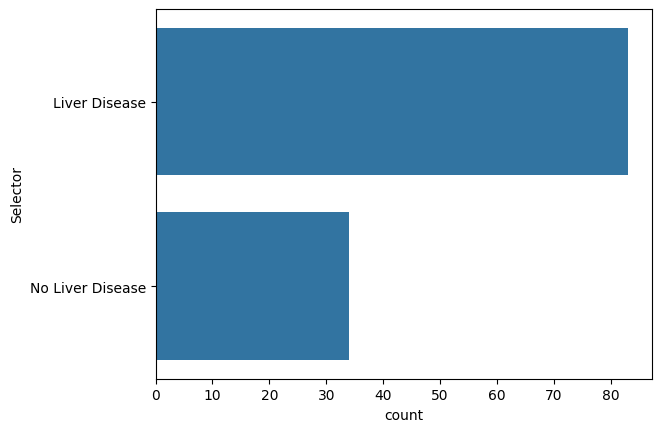

In [16]:
sns.countplot(data=y_test.replace(liver_disease_mapping))

In [17]:
print("We have {} training records".format(len(X_train)))
print("We have {} testing records".format(len(X_test)))

We have 466 training records
We have 117 testing records


We need to use cross validation hyperparameter tuning.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 5 - Hyperparameter tuning & Train ML

We will train KNN anf XGBoost to compare classification performance. 

In [19]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from IPython.display import clear_output

def objective(trial):
    params = {
            "n_neighbors": trial.suggest_int("n_neighbors", 3, 50),
            "weights":     trial.suggest_categorical("weights", ["uniform", "distance"]),
            "algorithm":   trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
            "leaf_size":   trial.suggest_int("leaf_size", 10, 60),
            "p":           trial.suggest_int("p", 1, 2),  # 1 = Manhattan, 2 = Euclidean
            "metric":      trial.suggest_categorical("metric", ["minkowski", "euclidean", "manhattan"]),
            }
    
    model = KNeighborsClassifier(**params)
    scores = cross_val_score(
        model, df_ml_input_scaled, df_ml_output,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )    
    return scores.mean()  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)
clear_output()

In [20]:
knn = KNeighborsClassifier(**study.best_params)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(algorithm='kd_tree', leaf_size=14, metric='manhattan',
                     n_neighbors=39, p=1, weights='distance')

In [21]:
from xgboost import XGBClassifier

def objective(trial):
    params = {
        'n_estimators'       : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'          : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'   : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'gamma'              : trial.suggest_float('gamma', 0.0, 1.0),
        'eval_metric'        : 'auc',
        'verbosity'          : 0
    }

    model = XGBClassifier(**params)
    scores = cross_val_score(
        model, df_ml_input, df_ml_output,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )    
    return scores.mean()  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)
clear_output()

In [22]:
xg = XGBClassifier(**study.best_params)
xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.929634449047167, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.7365287401468578, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.10264572176296603,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=270, n_jobs=None,
              num_parallel_tree=None, ...)

# Step 6 - Evaluation

In [23]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    classification_report, confusion_matrix,
    f1_score, accuracy_score, auc
)

val_proba_knn = knn.predict_proba(X_test)[:, 1]
val_labels_knn = (val_proba_knn >= 0.5).astype(int)       

print('='*50)
print('📊 FULL EVALUATION REPORT FOR KNN')
print('='*50)
print(f'ROC-AUC Score  : {roc_auc_score(y_test, val_proba_knn):.5f}')
print(f'Accuracy       : {accuracy_score(y_test, val_labels_knn):.5f}')
print(f'F1 Score       : {f1_score(y_test, val_labels_knn):.5f}')
print(f'\n📋 Classification Report:')
val_labels_knn = pd.Series(val_labels_knn) 
print(classification_report(y_test.replace(liver_disease_mapping), val_labels_knn.replace(liver_disease_mapping)))

📊 FULL EVALUATION REPORT FOR KNN
ROC-AUC Score  : 0.62651
Accuracy       : 0.70940
F1 Score       : 0.00000

📋 Classification Report:
                  precision    recall  f1-score   support

   Liver Disease       0.71      1.00      0.83        83
No Liver Disease       0.00      0.00      0.00        34

        accuracy                           0.71       117
       macro avg       0.35      0.50      0.41       117
    weighted avg       0.50      0.71      0.59       117



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samp

In [24]:
val_proba_xg = xg.predict_proba(X_test)[:, 1]
val_labels_xg = (val_proba_xg >= 0.5).astype(int)       

print('='*50)
print('📊 FULL EVALUATION REPORT FOR XGBoost')
print('='*50)
print(f'ROC-AUC Score  : {roc_auc_score(y_test, val_proba_xg):.5f}')
print(f'Accuracy       : {accuracy_score(y_test, val_labels_xg):.5f}')
print(f'F1 Score       : {f1_score(y_test, val_labels_xg):.5f}')
print(f'\n📋 Classification Report:')
val_labels_xg = pd.Series(val_labels_xg) 
print(classification_report(y_test.replace(liver_disease_mapping), val_labels_xg.replace(liver_disease_mapping)))

📊 FULL EVALUATION REPORT FOR XGBoost
ROC-AUC Score  : 0.62615
Accuracy       : 0.64957
F1 Score       : 0.34921

📋 Classification Report:
                  precision    recall  f1-score   support

   Liver Disease       0.74      0.78      0.76        83
No Liver Disease       0.38      0.32      0.35        34

        accuracy                           0.65       117
       macro avg       0.56      0.55      0.55       117
    weighted avg       0.63      0.65      0.64       117



/tmp/ipykernel_16/2694179724.py:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


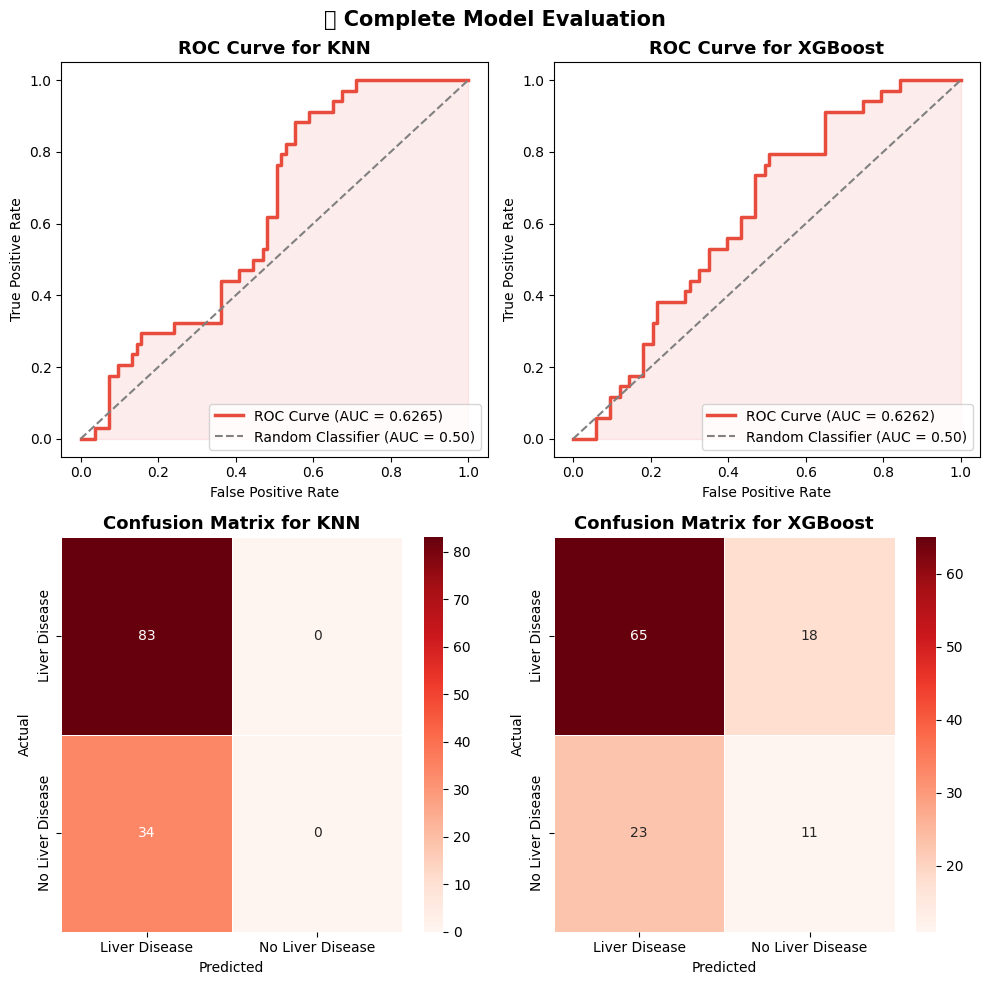

In [25]:
fig, axarr = plt.subplots(2, 2, figsize=(10, 10))
axes = axarr.ravel()

# ---- Plot 1: ROC Curve ----
fpr, tpr, _ = roc_curve(y_test, val_proba_knn)
roc_auc_val = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#E74C3C', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
             label='Random Classifier (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve for KNN', fontweight='bold', fontsize=13)
axes[0].legend(loc='lower right')

cm = confusion_matrix(y_test, val_labels_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            ax=axes[2], linewidths=0.5,
            xticklabels=['Liver Disease', 'No Liver Disease'],
            yticklabels=['Liver Disease', 'No Liver Disease'],)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix for KNN', fontweight='bold', fontsize=13)

fpr, tpr, _ = roc_curve(y_test, val_proba_xg)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#E74C3C', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
             label='Random Classifier (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve for XGBoost', fontweight='bold', fontsize=13)
axes[1].legend(loc='lower right')

cm = confusion_matrix(y_test, val_labels_xg)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            ax=axes[3], linewidths=0.5,
            xticklabels=['Liver Disease', 'No Liver Disease'],
            yticklabels=['Liver Disease', 'No Liver Disease'],)
axes[3].set_xlabel('Predicted')
axes[3].set_ylabel('Actual')
axes[3].set_title('Confusion Matrix for XGBoost', fontweight='bold', fontsize=13)

plt.suptitle('📊 Complete Model Evaluation', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

### KNN always suggests that input indicates presence of liver disease.